In [123]:
import os
import torch
import torchaudio
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchaudio.transforms import MelSpectrogram

In [125]:
metadata_path = "/UrbanSound8K.csv"
dataset_path = "/UrbanSound8K/audio"

In [127]:
metadata=pd.read_csv(metadata_path)

In [129]:
mel_transform=MelSpectrogram(sample_rate=22050,n_mels=128)

/home/bizmotion/anaconda3/lib/python3.12/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [131]:
class UrbanSoundDataset(Dataset):
    def __init__(self,metadata,audio_dir,transform=None):
        self.metadata=metadata
        self.audio_dir=audio_dir
        self.transform=transform
    def __len__(self):
        return len(self.metadata)

    def __getitem__(self,idx):
        audio_path=os.path.join(self.audio_dir,'fold'+ str(self.metadata.iloc[idx]['fold']), self.metadata.iloc[idx]['slice_file_name'])
        label=self.metadata.iloc[idx]['classID']
        audio,sr=librosa.load(audio_path,sr=22050)
        if self.transform:
            audio=self.transform(torch.tensor(audio))
        audio=audio/torch.max(audio)
        return audio,label
    

In [133]:
import torch.nn.utils.rnn as rnn_utils

def pad_mel_spectrograms(batch):
    """
    Custom collate function to pad mel-spectrograms to the same size within a batch.
    """
    mel_spectrograms = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])
    
    # Find the max width (time axis) and height (frequency axis) for padding
    max_height = max([mel.shape[0] for mel in mel_spectrograms])
    max_width = max([mel.shape[1] for mel in mel_spectrograms])

    # Pad each mel-spectrogram to (max_height, max_width)
    mel_spectrograms_padded = []
    for mel in mel_spectrograms:
        pad_height = max_height - mel.shape[0]
        pad_width = max_width - mel.shape[1]
        
        # Pad (top, bottom, left, right) - Fill with zeros
        padded_mel = torch.nn.functional.pad(mel, (0, pad_width, 0, pad_height), mode='constant', value=0)
        mel_spectrograms_padded.append(padded_mel)
    
    # Stack the padded mel-spectrograms into a single tensor
    mel_spectrograms_padded = torch.stack(mel_spectrograms_padded)
    
    return mel_spectrograms_padded, labels

In [136]:
dataset = UrbanSoundDataset(metadata, dataset_path, transform=mel_transform)

# Split the dataset into training and testing sets
train_data, test_data = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)
train_loader = DataLoader(dataset, batch_size=32, sampler=torch.utils.data.SubsetRandomSampler(train_data),collate_fn=pad_mel_spectrograms)
test_loader = DataLoader(dataset, batch_size=32, sampler=torch.utils.data.SubsetRandomSampler(test_data),collate_fn=pad_mel_spectrograms)

In [139]:
import torch.nn as nn
import torch.nn.functional as F

In [141]:
class SoundCNN(nn.Module):
    def __init__(self):
        super(SoundCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.global_pool = nn.AdaptiveAvgPool2d((16, 16))
        
        self.fc1 = nn.Linear(128 * 16 * 16, 128)  # Adjust input size based on Mel-spectrogram dimensions
        self.fc2 = nn.Linear(128, 10)  # 10 classes
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x=self.global_pool(x)
        x = x.view(-1, 128 * 16 * 16)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [143]:
import torch.optim as optim

In [145]:
model=SoundCNN()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [147]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SoundCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=(16, 16))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [149]:
epochs = 30
train_losses = []

In [151]:

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for mel_spectrograms, labels in train_loader:
        mel_spectrograms, labels = mel_spectrograms.to(device), labels.to(device)

        # Reshape for CNN input
        mel_spectrograms = mel_spectrograms.unsqueeze(1)
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(mel_spectrograms.float())
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

print("Training complete.")

Epoch 1/30, Loss: 1.8323
Epoch 2/30, Loss: 1.4079
Epoch 3/30, Loss: 1.1931
Epoch 4/30, Loss: 1.0472
Epoch 5/30, Loss: 0.9187
Epoch 6/30, Loss: 0.8201
Epoch 7/30, Loss: 0.7399
Epoch 8/30, Loss: 0.6808
Epoch 9/30, Loss: 0.5965
Epoch 10/30, Loss: 0.5318
Epoch 11/30, Loss: 0.4984
Epoch 12/30, Loss: 0.4402
Epoch 13/30, Loss: 0.4075
Epoch 14/30, Loss: 0.3789
Epoch 15/30, Loss: 0.3574
Epoch 16/30, Loss: 0.3304
Epoch 17/30, Loss: 0.3089
Epoch 18/30, Loss: 0.2696
Epoch 19/30, Loss: 0.2677
Epoch 20/30, Loss: 0.2496
Epoch 21/30, Loss: 0.2440
Epoch 22/30, Loss: 0.2314
Epoch 23/30, Loss: 0.2142
Epoch 24/30, Loss: 0.2160
Epoch 25/30, Loss: 0.2106
Epoch 26/30, Loss: 0.1839
Epoch 27/30, Loss: 0.1839
Epoch 28/30, Loss: 0.1917
Epoch 29/30, Loss: 0.1705
Epoch 30/30, Loss: 0.1579
Training complete.


In [153]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for mel_spectrograms, labels in test_loader:
        mel_spectrograms, labels = mel_spectrograms.to(device), labels.to(device)
        mel_spectrograms = mel_spectrograms.unsqueeze(1)
        
        outputs = model(mel_spectrograms.float())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total}%")

Test Accuracy: 83.17115054378935%


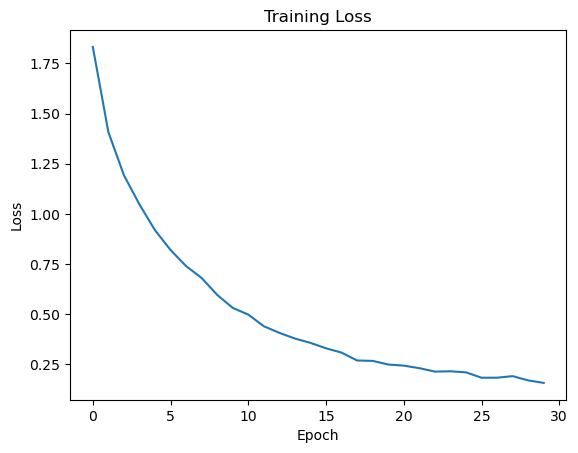

In [154]:
import matplotlib.pyplot as plt

# Plot training loss
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()